# Image Processing (Object Tracking)
In this experiment, we'll build a tracker out of morphologizing an image by applying color filters.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from imageio.v3 import *
import skimage
from skimage import morphology

To process an image, we import the Gasoline video from Physics 191, and limit the frames we use to when the motion has happened to limit memory use.

Based on the other trackers motion happened at Frame # 62 (if your index number is zero) to # 82.

However, we'll start with frame 62 to learn about image processing, and then apply them iteratively across the video

## Fundamentals of Image Processing

Here, we'll plot the image. This time, starting with Frame #62.

The frame size for reading (864, 1920) is different from the source frame size (1920, 864).


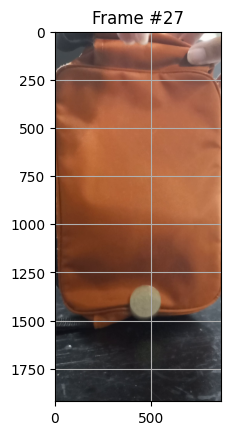

In [22]:
frames = [] # where we'll store frames of interest
"""
for id, frame in enumerate(imiter("Castor1.mp4")):
    frames.append(frame)
print(frames)
"""
for id, frame in enumerate(imiter("20260306_151943.mp4")):
    # Notice how this loop is essentially where you'll be doing
    # your per-frame image processing. Remember this pattern.
    if id == 27:
        break

fig, ax = plt.subplots()
# Difference between imshow and matshow? imshow appears to have
# a bit of blur while matshow displays the pixel values as-is. Why?
ax.imshow(frame)
ax.set_title(f"Frame #{id}")
ax.grid(True)

Now, we crop the image, to make the object tracking more visually manageable.

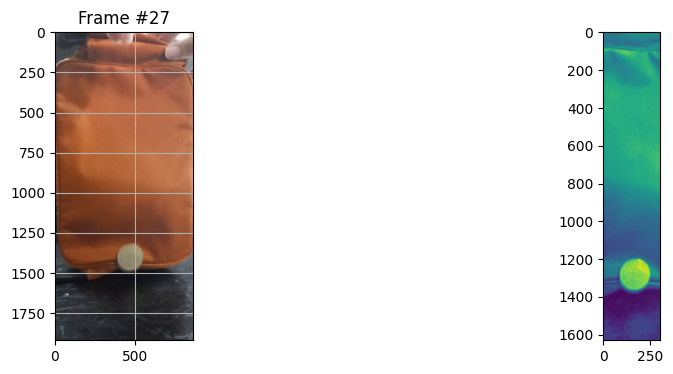

In [3]:
fig, (lax, rax) = plt.subplots(1, 2, figsize=(12, 4))
lax.imshow(frame)
lax.set_title(f"Frame #{id}")
lax.grid(True)

###       top-down   left-right  color chan.
crop = frame[120:1750, 300:600, 1] # In green channel,
## this is where the ball is most prominent
rax.imshow(crop)

The image on the right shows an image where the ball is barely discernible.

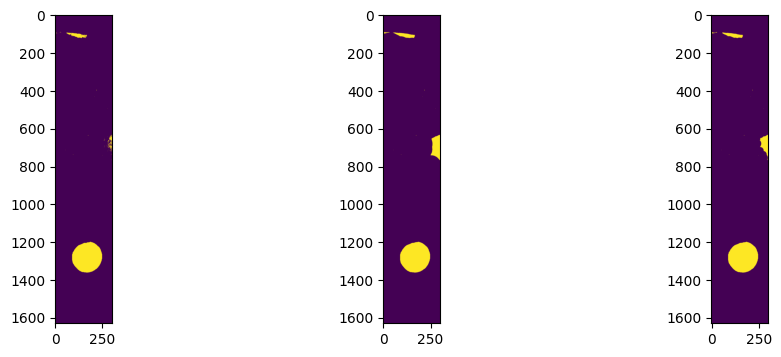

In [4]:
binarized = crop > 120 # Since the brightest spots have
# binarized_fin = binarized > 85
# intensity 100+

footprint = morphology.disk(radius=50)
test1 = morphology.closing(binarized, footprint)

footprint2 = morphology.disk(radius=20)
test2 = morphology.closing(binarized, footprint2)


fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(binarized)
axs[1].imshow(test1)
axs[2].imshow(test2)

We have discovered that the motion started at Frame # 20, and ending at Frame # 27. We're now ready to make the tracking.

## Center of Mass Tracking

Here, we'll use scipy's ndimage center of mass codes, to locate the center. We test it first with a single frame, which is again, Frame 27.

(np.float64(1129.7736744790366), np.float64(169.2623557043626))


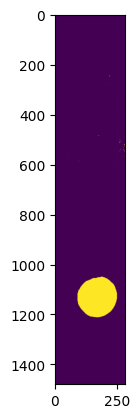

In [7]:
# Import the necessary model
from scipy import ndimage

# Filter the image even more
final_image = binarized[150:1631, 0:280]

# Test the image, once done, comment out the code below
plt.imshow(final_image)

# Find the center of mass
com = ndimage.center_of_mass(final_image)
print(com)

Now, we know the output of the center-of-mass function. We now apply it iteratively across the frames where our coin is moving.

In [20]:
# Define the trajectory function
def trajectory(start, end):
    x_coords = []
    y_coords = []
    for id, timeframe in enumerate(imiter("20260306_151943.mp4")):
        if id < start: # Since range is an exclusive end
            continue # Makes sure that the frame continues
        
        if id > end:
            break

        # Crop 
        #      up-down,       left-right, color channel
        crop = timeframe[270:1750, 300:580,    1] # green channel
        # change color channel when appropriate
        # binarize
        binarized = crop > 120 # threshold brightness
        y, x = ndimage.center_of_mass(binarized)
        y_coords.append(y)
        x_coords.append(x)

    return y_coords, x_coords

            

Implement the code now in our target frames

In [21]:
trajectory(20, 27) # implement 

The frame size for reading (864, 1920) is different from the source frame size (1920, 864).


([np.float64(107.14628117743989),
  np.float64(245.7609010395607),
  np.float64(508.51737792718365),
  np.float64(816.3706355769813),
  np.float64(1226.1564716471646),
  np.float64(1153.9982770503102),
  np.float64(1121.9385614385615),
  np.float64(1129.7736744790366)],
 [np.float64(173.33036226999226),
  np.float64(183.40696779579218),
  np.float64(195.33391259757278),
  np.float64(215.55547935534622),
  np.float64(226.7122592259226),
  np.float64(259.23880082701584),
  np.float64(178.50031786395422),
  np.float64(169.2623557043626)])

The frame size for reading (864, 1920) is different from the source frame size (1920, 864).


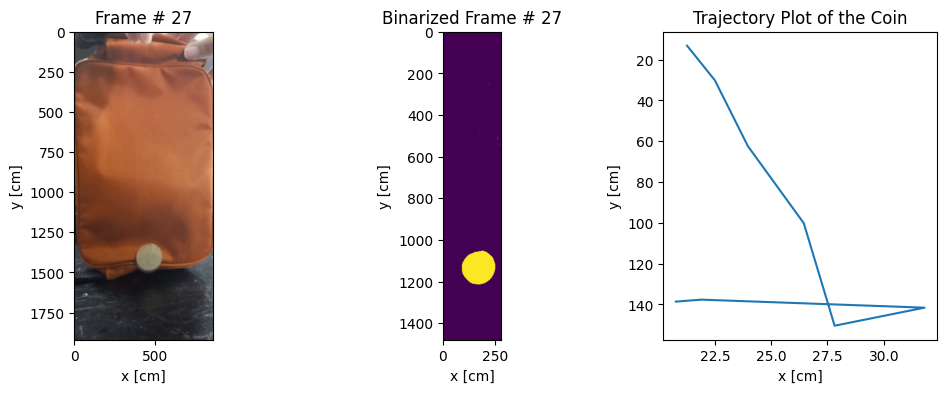

In [26]:
y, x = trajectory(20, 27)
y_fin = 0.1227*np.array(y) # Convert to cm, 0.1227 cm per pixel
x_fin = 0.1227*np.array(x)

## Make the code for the plot
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(frame) # Shows Frame # 27
axs[0].set_title("Frame # 27")
axs[0].set_xlabel("x [cm]")
axs[0].set_ylabel("y [cm]")
axs[1].set_title("Binarized Frame # 27") # Clean Frame
axs[1].imshow(final_image) # Image # 27 Binarized
axs[1].set_xlabel("x [cm]")
axs[1].set_ylabel("y [cm]")
axs[2].set_title("Trajectory Plot of the Coin")
axs[2].plot(x_fin, y_fin, label='coin trajectory')
axs[2].set_xlabel("x [cm]")
axs[2].set_ylabel("y [cm]")
axs[2].invert_yaxis() # Shift the origin to the top
plt.savefig("Final_plot.pdf")